#**Project** **Name** **:**
###**'Google Play Store' Data Analysis**
##**Project Type**: Exploratory Data Analysis
##**Contribution**: Individual

#**Project Summary :**
####**This project analyzes the content available on Amazon Prime Video to identify meaningful trends and insights that can support content strategy and investment decisions. The analysis focuses on content types, genres, production countries, release trends, ratings, and the participation of actors and directors.**
####**The project uses two datasets, titles.csv and credits.csv. The titles dataset contains information such as title, type, release year, genres, production countries, IMDb ratings, IMDb votes, and TMDb ratings. The credits dataset provides information about actors and directors associated with each title. Python, Pandas, NumPy, Matplotlib, and Seaborn were used for data cleaning, exploration, analysis, and visualization.**
####**During the analysis, missing values and data quality issues were examined and handled appropriately. The datasets were also combined to analyze actor and director participation. Seven visualizations were created to answer key business questions related to content diversity, production regions, content growth, ratings, and talent representation.**
####**Overall, the project provides a data-driven view of Amazon Prime Video's content portfolio and highlights opportunities to diversify content, expand international representation, maintain high-quality titles, and use historical trends to guide future content decisions.**

#**GitHub Link :**

##**Problem Statement :**
####**With millions of apps available on the Google Play Store, businesses and app developers face intense competition to attract and retain users. This project aims to analyze app-related factors such as user engagement, ratings, reviews, installations, app size, pricing, and category to understand their influence on app success and user satisfaction. Using exploratory data analysis and visualizations, we will identify patterns and relationships among these factors and derive actionable insights that can help businesses and app developers make data-driven decisions to improve existing apps and develop successful new ones.**

##**Business Objective :**
####**The primary objective of this project is to identify the key factors that influence app success, user engagement, and user satisfaction on the Google Play Store.**

##**Let's Begin!**

##**Importing the required libraries.**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from seaborn.widgets import color_palette
import plotly
import plotly.express as px


In [3]:
# pandas displays all columns
pd.set_option('display.max_columns', None)

In [4]:
# Mount Google Drive to access files stored in Drive
from google.colab import drive

drive.mount('/content/drive')
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
#file locations
file_location_credits = '/content/credits.csv'
file_location_titles = '/content/titles.csv'

In [6]:
#converting data to dataf-rame
credits_data = pd.read_csv(file_location_credits)
titles_data = pd.read_csv(file_location_titles)

In [7]:
#shows first five rows of credits data
credits_data.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [8]:
#shows first five rows of titles data.
titles_data.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [9]:
# this shows last 5 rows of credits data.
credits_data.tail()

,person_id,id,name,character,role
124230,1938589,tm1054116,Sangam Shukla,Madhav,ACTOR
124231,1938565,tm1054116,Vijay Thakur,Sanjay Thakur,ACTOR
124232,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124233,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR
124234,1938620,tm1054116,Vishwa Bhanu,NaN,DIRECTOR


In [10]:
# this shows last 5 rows of titles data.
titles_data.tail()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
9866,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,NaN,93,['drama'],['US'],NaN,tt7672388,5.3,20.0,1.406,NaN
9867,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,NaN,55,['comedy'],['US'],NaN,tt15041600,NaN,NaN,0.600,NaN
9868,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,NaN,116,['crime'],['IN'],NaN,NaN,NaN,NaN,1.960,NaN
9869,tm1054116,Baikunth,MOVIE,"This story is about prevalent caste problem, e...",2021,NaN,72,"['family', 'drama']",[],NaN,tt14331982,8.4,49.0,0.645,NaN
9870,ts275838,Waking Up Eighty,SHOW,"Kara Stewart, 16, is fed up with just about ev...",2021,NaN,10,['drama'],[],1.0,tt13542552,NaN,NaN,NaN,NaN


In [11]:
# to get quick summary of credits_data
credits_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124235 entries, 0 to 124234
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124235 non-null  int64 
 1   id         124235 non-null  object
 2   name       124235 non-null  object
 3   character  107948 non-null  object
 4   role       124235 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB


In [12]:
#to get quick summary of titles_data
titles_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

In [13]:
# number of rows and columns in credits_data
credits_data.shape

(124235, 5)

In [14]:
# number of rows and columns in titles_data
titles_data.shape

(9871, 15)

###**Copy the credits_data so that the original data remains unchanged.**

In [15]:
# credits_df will be used further for analysis.
credits_df = credits_data.copy()

###**Copy the titles_data so that the original data remains unchanged.**

In [16]:
# titles_df will be used further for analysis.
titles_df = titles_data.copy()

In [17]:
# this gives us the statistical summary of numerical columns of credits_df
credits_df.describe()

,person_id
count,1.242350e+05
mean,4.064737e+05
std,5.616296e+05
min,1.000000e+00
25%,3.899200e+04
50%,1.339490e+05
75%,5.712560e+05
max,2.371153e+06


In [18]:
# this gives us the statistical summary of numerical columns in. titles_df
titles_df.describe()

,release_year,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9871.000000,9871.000000,1357.000000,8850.000000,8.840000e+03,9324.000000,7789.000000
mean,2001.327221,85.973052,2.791452,5.976395,8.533614e+03,6.910204,5.984247
std,25.810071,33.512466,4.148958,1.343842,4.592015e+04,30.004098,1.517986
min,1912.000000,1.000000,1.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,1995.500000,65.000000,1.000000,5.100000,1.170000e+02,1.232000,5.100000
50%,2014.000000,89.000000,1.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,2018.000000,102.000000,3.000000,6.900000,2.236250e+03,5.634000,6.900000
max,2022.000000,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


###**Step 1 : Data preparation and cleaning.**
###** checking for null or missing value **

In [19]:
# checking for null values in credits_df.
credits_df.isnull()


,person_id,id,name,character,role
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
124230,False,False,False,False,False
124231,False,False,False,False,False
124232,False,False,False,False,False
124233,False,False,False,False,False


In [20]:
# checking for null values in titles_df.
titles_df.isnull()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9866,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True
9867,False,False,False,False,False,True,False,False,False,True,False,True,True,False,True
9868,False,False,False,False,False,True,False,False,False,True,True,True,True,False,True
9869,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True


In [21]:
# checking which column in credits_df has null values and sort them in descending order.
credits_df.isnull().sum().sort_values(ascending = False)

,0
character,16287
person_id,0
id,0
name,0
role,0


In [22]:
# checking which column in titles_df has null values and sort them in descending order.
titles_df.isnull().sum().sort_values(ascending=False)

,0
seasons,8514
age_certification,6487
tmdb_score,2082
imdb_votes,1031
imdb_score,1021
imdb_id,667
tmdb_popularity,547
description,119
runtime,0
title,0


###**Taking care of 'character' column in credits_df.**

In [23]:
# count roles with number of null character values.
credits_df[credits_df['character'].isnull()]['role'].value_counts()

,count
role,
DIRECTOR,8389
ACTOR,7898


In [24]:
# fill missing character names with a placeholder to retain the values.
credits_df['character'].fillna('Not Specified', inplace = True)

/tmp/ipykernel_3631/962096246.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  credits_df['character'].fillna('Not Specified', inplace = True)


In [25]:
# verifying that cleanup worked(ther character column should be 0 now)
credits_df.isnull().sum()

,0
person_id,0
id,0
name,0
character,0
role,0


###**Investigating the null values in titles_df.**

In [26]:
# Handling 'seasons': Fill with 0 because movies do not have seasons
titles_df['seasons'].fillna(0, inplace=True)

/tmp/ipykernel_3631/3160769883.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titles_df['seasons'].fillna(0, inplace=True)


In [27]:
# Handling Categorical missing data
titles_df['age_certification'].fillna('Not Rated', inplace=True)
titles_df['description'].fillna('No description available', inplace=True)
titles_df['imdb_id'].fillna('Unknown', inplace=True)

/tmp/ipykernel_3631/1790286118.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titles_df['age_certification'].fillna('Not Rated', inplace=True)
/tmp/ipykernel_3631/1790286118.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

In [28]:
# handling Numerical missing data with Median Imputation
numerical_cols = ['tmdb_score', 'imdb_votes', 'imdb_score', 'tmdb_popularity']
for col in numerical_cols:
    titles_df[col] = titles_df[col].fillna(titles_df[col].median())


In [29]:
# Verify the clean-up
titles_df.isnull().sum()

,0
id,0
title,0
type,0
description,0
release_year,0
age_certification,0
runtime,0
genres,0
production_countries,0
seasons,0


###**Step 2 : Duplicate Handling and Outlier treatment.**

In [30]:
# checking duplocate rows in credits_df
print("credits_df duplicates:", credits_df.duplicated().sum())


credits_df duplicates: 56


In [31]:
# checking for duplocate rows in titles_df
print("titles_df duplicates:", titles_df.duplicated().sum())

titles_df duplicates: 3


In [32]:
# deleting duplicate rows from both the date-frames.
credits_df = credits_df.drop_duplicates()
titles_df = titles_df.drop_duplicates()

In [33]:
# verifying the drop was successful.
print('credit_df duplicates:', credits_df.duplicated().sum())
print('titles_df duplicates:', titles_df.duplicated().sum())

credit_df duplicates: 0
titles_df duplicates: 0


In [34]:
# View statistical summary of numerical columns to spot extreme min/max values
titles_df[['runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']].describe()

,runtime,seasons,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
count,9868.000000,9868.000000,9868.000000,9.868000e+03,9868.000000,9868.000000
mean,85.979124,0.383867,5.989309,7.692922e+03,6.669589,5.987465
std,33.515714,1.813821,1.273147,4.353213e+04,29.182253,1.348592
min,1.000000,0.000000,1.100000,5.000000e+00,0.000011,0.800000
25%,65.000000,0.000000,5.300000,1.380000e+02,1.307750,5.400000
50%,89.000000,0.000000,6.100000,4.625000e+02,2.536000,6.000000
75%,102.000000,0.000000,6.800000,1.763250e+03,5.300250,6.700000
max,549.000000,51.000000,9.900000,1.133692e+06,1437.906000,10.000000


###**'runtime' column in titles_df is looking a bit suspicious so lets dive a bit into it.**

In [35]:
# Inspecting extreme 'runtime' column outliers
extreme_runtimes = titles_df[(titles_df['runtime'] < 10) | (titles_df['runtime'] > 300)]
extreme_runtimes[['title', 'type', 'runtime', 'genres']]

,title,type,runtime,genres
904,Custer's Last Stand,MOVIE,328,"['western', 'history', 'romance', 'war']"
1736,Pinkfong! Halloween Songs,SHOW,1,"['music', 'animation', 'family']"
1902,Pingu,SHOW,9,"['comedy', 'family', 'animation', 'european']"
2370,Bananas in Pyjamas,SHOW,8,"['animation', 'comedy', 'family', 'fantasy']"
2401,Incognito,MOVIE,1,"['crime', 'thriller', 'romance']"
...,...,...,...,...
9088,Monster Pets: A Hotel Transylvania Short,MOVIE,6,"['fantasy', 'comedy']"
9169,Akedo: Ultimate Arcade Warriors,SHOW,6,['animation']
9587,Tayo and Little Wizards,SHOW,1,[]
9739,Pinkfong Job Songs,SHOW,2,[]


###**This is legitimate data, so we will keep it.**

###**Step 3 : Data Transformation**

In [36]:
# Removing the brackets and quotes from the lists
titles_df['genres'] = titles_df['genres'].str.replace(r"\[|\]|'", "", regex=True)
titles_df['production_countries'] = titles_df['production_countries'].str.replace(r"\[|\]|'", "", regex=True)


###**Step 4 : Merge the two data-frames.**

In [37]:
# merging the titles_df and credits_df on common column 'id'.
df_merged = titles_df.merge(credits_df, on='id', how='inner')

In [38]:
# display the shape of the new merged_df
print('Merged data-frame', df_merged.shape)

Merged data-frame (124179, 19)


###**Step 5 : Visualization**

####**First Visualization :  A Countplot**

/tmp/ipykernel_3631/1392258497.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=titles_df, x='type', palette='Set2')


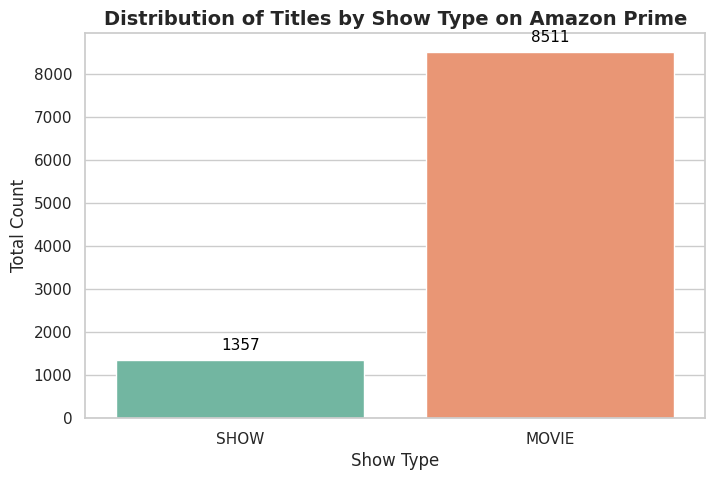

In [39]:
# Set the style for the visualizations
sns.set_theme(style="whitegrid")

# Create the figure
plt.figure(figsize=(8, 5))

# Plot the distribution of Movies vs TV Shows using the titles dataset
ax = sns.countplot(data=titles_df, x='type', palette='Set2')

# Add titles and labels
plt.title('Distribution of Titles by Show Type on Amazon Prime', fontsize=14, fontweight='bold')
plt.xlabel('Show Type', fontsize=12)
plt.ylabel('Total Count', fontsize=12)

# Add data labels on top of the bars for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

#####**We can clearly see from 'countplot' that movies overwhelmingly dominate TV Shows by approximately 86%.**

####**Second Visualization : A Lineplot**

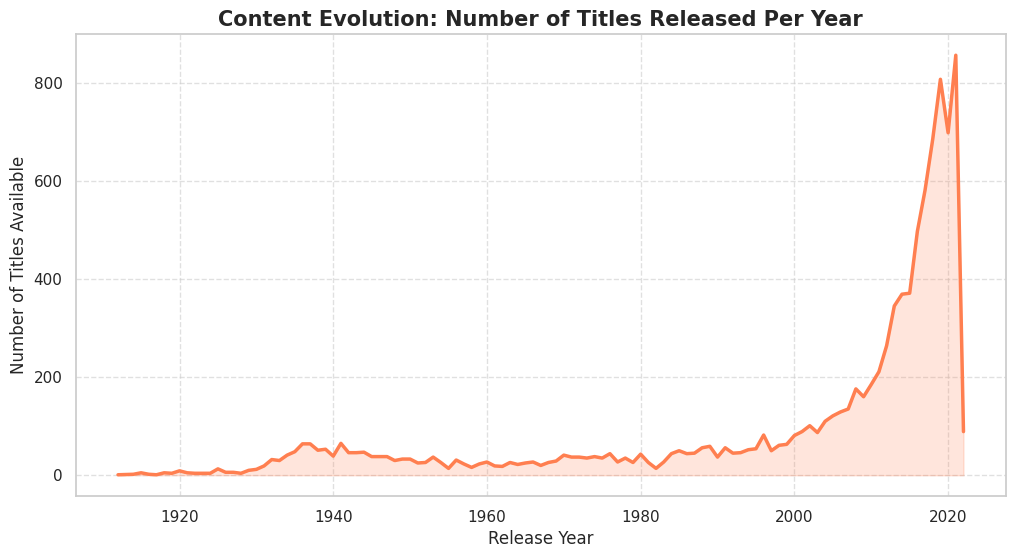

In [40]:
# Count the number of titles per release year and sort by year
yearly_trends = titles_df['release_year'].value_counts().sort_index()

# Create the figure
plt.figure(figsize=(12, 6))

# Plot the line chart
sns.lineplot(x=yearly_trends.index, y=yearly_trends.values, color='coral', linewidth=2.5)

# Add titles and labels
plt.title('Content Evolution: Number of Titles Released Per Year', fontsize=15, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles Available', fontsize=12)

# Add a grid for easier reading
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight the area under the line for a polished look
plt.fill_between(yearly_trends.index, yearly_trends.values, color='coral', alpha=0.2)

plt.show()

#####**The graph demonstrates a clear upward trend in content volume over time, with releases increasing steadily after the 1980s and accelerating rapidly from 2010 onwards. The highest volume of content addition occurred between 2020 and 2021, highlighting the platform's aggressive recent growth and the industry-wide "streaming boom." The sharp decline observed in 2022 is likely due to the dataset being captured mid-year (incomplete data) rather than an actual reduction in Amazon Prime's content production.**

####**Third Visualization : A barplot**

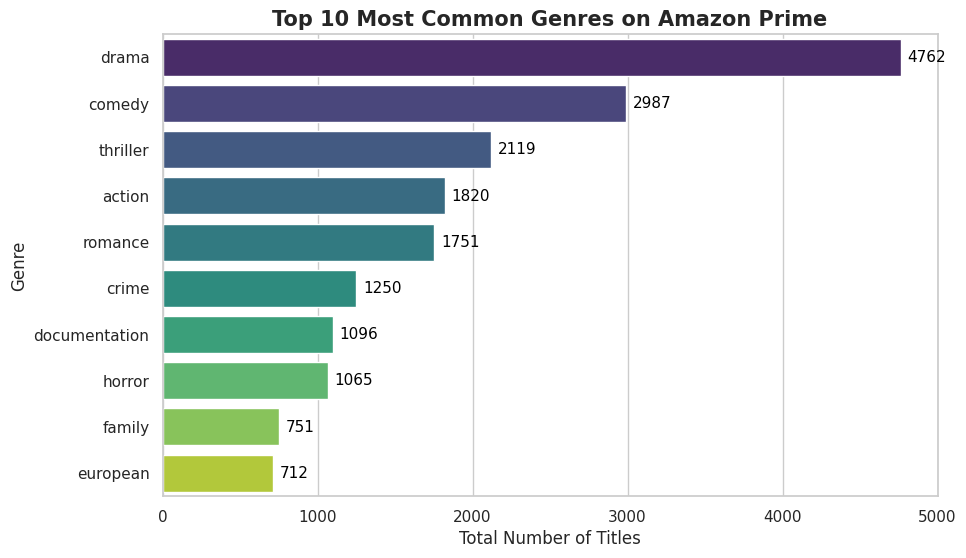

In [41]:
# 1. Split the comma-separated genres and explode them into individual rows
all_genres = titles_df['genres'].str.split(', ').explode()

# 2. Count the occurrences of each genre and grab the top 10 (excluding empty ones if any exist)
top_10_genres = all_genres[all_genres != ''].value_counts().head(10)

# 3. Create the figure
plt.figure(figsize=(10, 6))

# 4. Plot the horizontal bar chart
ax = sns.barplot(x=top_10_genres.values, y=top_10_genres.index, hue=top_10_genres.index, palette='viridis', legend=False)

# 5. Add titles and labels
plt.title('Top 10 Most Common Genres on Amazon Prime', fontsize=15, fontweight='bold')
plt.xlabel('Total Number of Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)

# 6. Add data labels to the end of each bar for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                fontsize=11, color='black', xytext=(5, 0),
                textcoords='offset points')

plt.show()

#####**Drama dominates Amazon Prime's content catalog with 4,762 titles, significantly exceeding Comedy and Thriller. The relatively low representation of Family and European content may indicate opportunities for catalog expansion in these categories.**


####**Fourth Visulization : Scatter Plot**

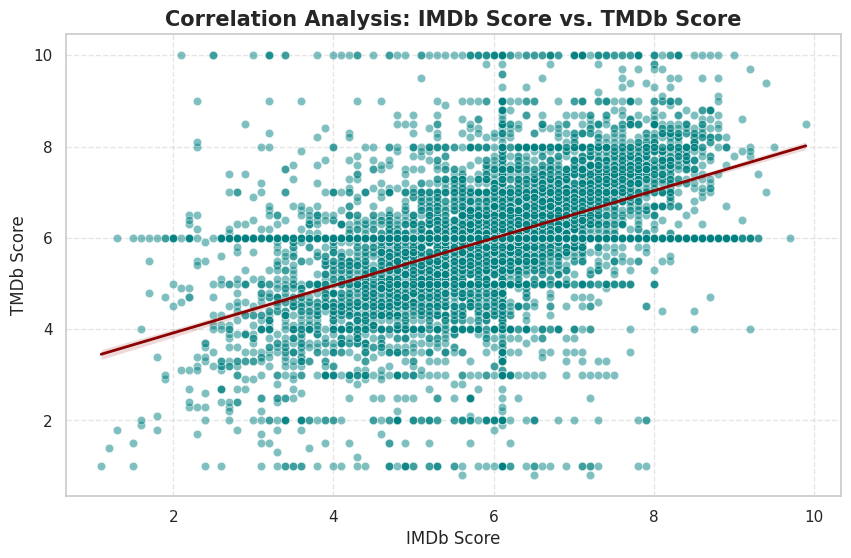

Correlation Coefficient: 0.49


In [42]:
# Create the figure
plt.figure(figsize=(10, 6))

# Plot the scatter plot using the titles dataset
sns.scatterplot(data=titles_df, x='imdb_score', y='tmdb_score', alpha=0.5, color='teal')

# Add a trendline to show the correlation clearly
sns.regplot(data=titles_df, x='imdb_score', y='tmdb_score', scatter=False, color='darkred', line_kws={"linewidth": 2})

# Add titles and labels
plt.title('Correlation Analysis: IMDb Score vs. TMDb Score', fontsize=15, fontweight='bold')
plt.xlabel('IMDb Score', fontsize=12)
plt.ylabel('TMDb Score', fontsize=12)

# Add gridlines
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Calculate the actual correlation coefficient mathematically
correlation = titles_df['imdb_score'].corr(titles_df['tmdb_score'])
print(f"Correlation Coefficient: {correlation:.2f}")

#####**The scatter plot shows a moderate positive relationship between IMDb scores and TMDB scores, with a correlation coefficient of 0.49. This indicates that titles receiving higher ratings on IMDb generally tend to receive higher ratings on TMDB as well. However, the relationship is not very strong, suggesting that the two platforms do not always rate titles similarly. Other factors may influence the ratings given by users on each platform.**

####**Fifth Visualization : Bar Plot(Actor & Director Participation by Volume)**

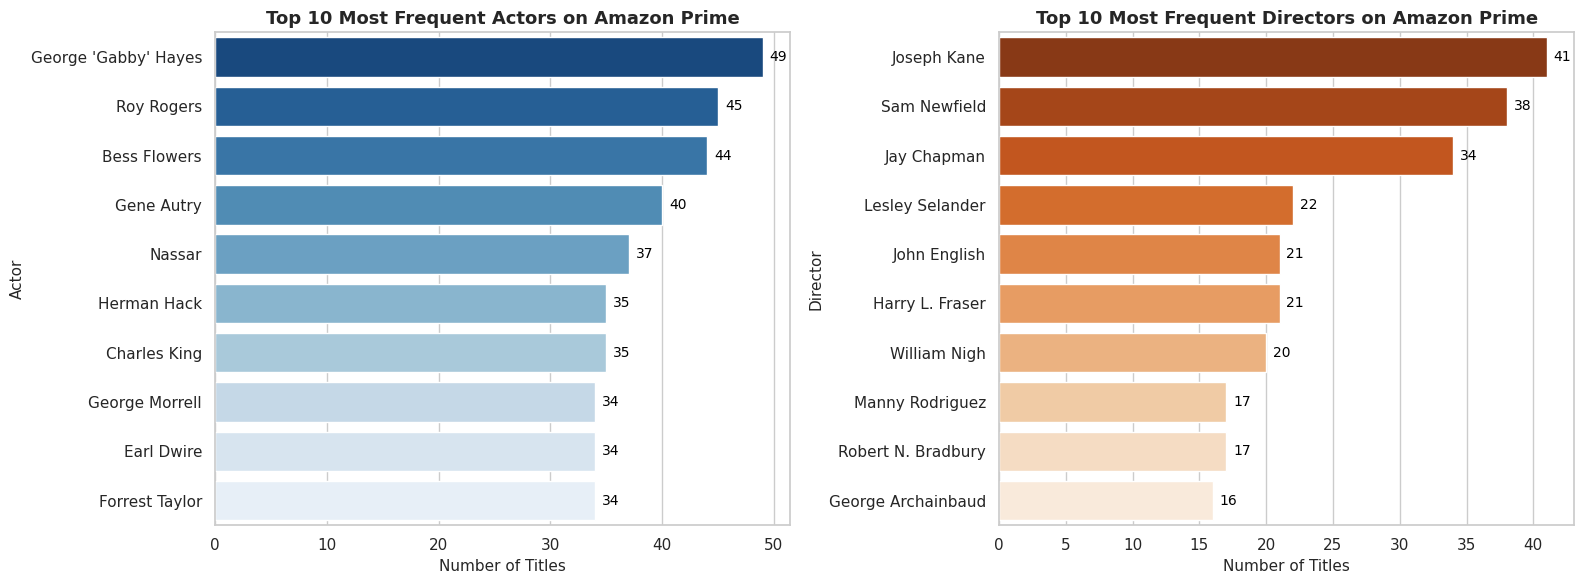

In [44]:
# 1. Filter actors and directors from the merged dataset
top_actors = (
    df_merged[df_merged['role'] == 'ACTOR']['name']
    .value_counts()
    .head(10)
)

top_directors = (
    df_merged[df_merged['role'] == 'DIRECTOR']['name']
    .value_counts()
    .head(10)
)

# 2. Set up subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot Top Actors
sns.barplot(
    x=top_actors.values,
    y=top_actors.index,
    hue=top_actors.index,
    palette='Blues_r',
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Top 10 Most Frequent Actors on Amazon Prime', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Titles', fontsize=11)
axes[0].set_ylabel('Actor', fontsize=11)

# Annotate values for actors
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width())}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center',
                     fontsize=10, color='black', xytext=(5, 0),
                     textcoords='offset points')

# Plot Top Directors
sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    hue=top_directors.index,
    palette='Oranges_r',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Top 10 Most Frequent Directors on Amazon Prime', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Titles', fontsize=11)
axes[1].set_ylabel('Director', fontsize=11)

# Annotate values for directors
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_width())}',
                     (p.get_width(), p.get_y() + p.get_height() / 2.),
                     ha='left', va='center',
                     fontsize=10, color='black', xytext=(5, 0),
                     textcoords='offset points')

plt.tight_layout()
plt.show()

#####**The visualization identifies the top 10 actors and directors based on their frequency of participation across Amazon Prime titles. It highlights individuals who have contributed to a relatively large number of titles in the platform's catalog, indicating their strong representation across the available content.**


####**Sixth Visualization : A horizontal bar plot**

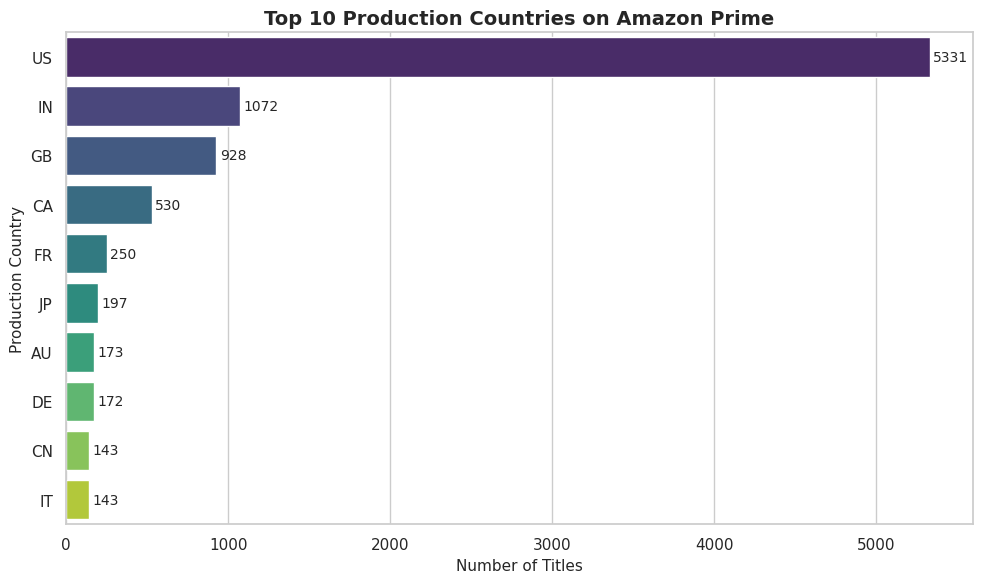

In [48]:
# Split multiple countries and create one row per country
all_countries = (
    titles_df['production_countries']
    .dropna()
    .str.split(', ')
    .explode()
)

# Remove blank country values
all_countries = all_countries[all_countries.str.strip() != '']

# Count titles for each country and select the top 10
top_10_countries = all_countries.value_counts().head(10)


plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_countries.values,
    y=top_10_countries.index,
    hue=top_10_countries.index,
    palette='viridis',
    legend=False
)

plt.title('Top 10 Production Countries on Amazon Prime',
          fontsize=14, fontweight='bold')

plt.xlabel('Number of Titles', fontsize=11)
plt.ylabel('Production Country', fontsize=11)

# Add values to the bars
for i, value in enumerate(top_10_countries.values):
    plt.text(value + 20, i, str(value),
             va='center', fontsize=10)

plt.tight_layout()
plt.show()

#####**United States dominates the content catalog with **5,331 titles**, significantly higher than India (**1,072**) and the United Kingdom (**988**). Canada, France, Japan, Australia, Germany, and Italy also contribute to the catalog, but with considerably fewer titles. Overall, the content library is strongly dominated by **US-produced content**, while other countries have a smaller representation.**


####**Seventh Visualization : A barplot**

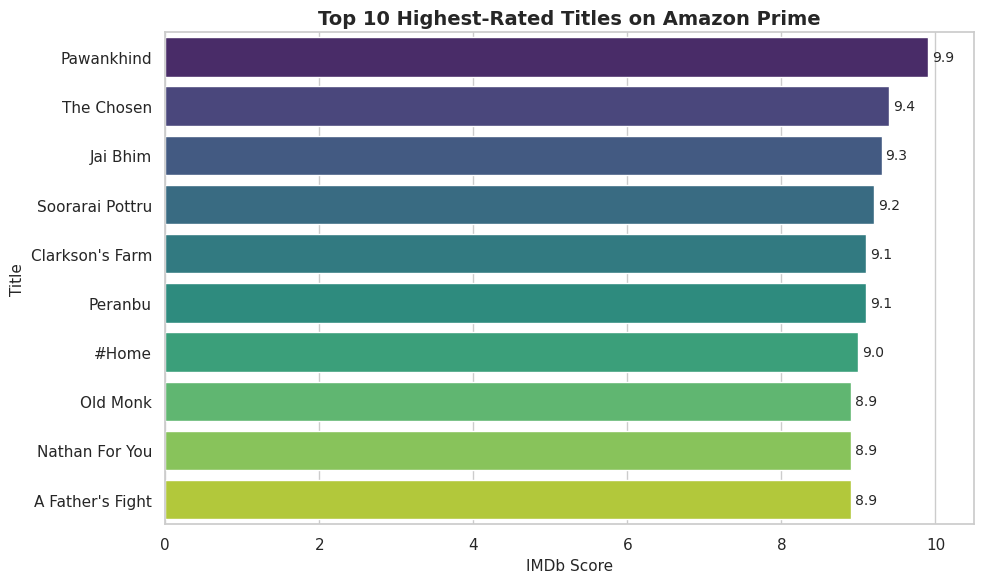

In [51]:
# Filter titles with at least 1,000 IMDb votes
high_rated_titles = titles_df[titles_df['imdb_votes'] >= 1000]

# Select the 10 highest-rated titles
top_10_rated = (
    high_rated_titles
    .sort_values('imdb_score', ascending=False)
    [['title', 'imdb_score', 'imdb_votes']]
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_10_rated,
    x='imdb_score',
    y='title',
    hue='title',
    palette='viridis',
    legend=False
)

plt.title(
    'Top 10 Highest-Rated Titles on Amazon Prime',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('IMDb Score', fontsize=11)
plt.ylabel('Title', fontsize=11)

# Add IMDb scores to the bars
for i, score in enumerate(top_10_rated['imdb_score']):
    plt.text(
        score + 0.05,
        i,
        f'{score:.1f}',
        va='center',
        fontsize=10
    )

plt.xlim(0, 10.5)
plt.tight_layout()
plt.show()

#####**The visualization shows that **Pawankhind** has the highest IMDb rating at **9.9**, followed by **The Chosen** at **9.4** and **Jai Bhim** at **9.3**. The remaining titles have ratings between **8.9 and 9.2**, indicating that all 10 selected titles have exceptionally high IMDb ratings.**

###**Business Questions Answered**

####**What genres and categories dominate Amazon Prime's content catalog?**
#####**The analysis shows that Movies dominate the Amazon Prime content catalog, accounting for approximately 86% of the titles, while TV Shows represent a much smaller proportion (Visualization 1: Distribution of Titles by Show Type). Among the different genres, Drama is the most common genre with 4,762 titles, followed by Comedy and Thriller (Visualization 3: Top 10 Most Common Genres). This indicates that Amazon Prime's catalog has a strong focus on movie content, with Drama being the most prominent genre.**

####**How is Amazon Prime's content distributed by production country?**
#####**The production-country analysis shows that the United States has the largest representation with 5,331 titles, followed by India with 1,072 titles and the United Kingdom with 988 titles (Visualization 6: Top 10 Production Countries). Canada, France, Japan, Australia, Germany, and Italy have considerably smaller representations. This shows that the catalog is strongly concentrated around US-produced content, while content from other countries provides additional geographic diversity.**

####**How has Amazon Prime's content library evolved over time?**
#####**The analysis shows a clear increase in the number of titles over time, particularly after the 1980s, with a much sharper increase from 2010 onwards (Visualization 2: Content Evolution Over Time). The highest volume of titles was observed around 2020–2021, indicating substantial growth in the platform's content library during the recent period. The decline in 2022 should be interpreted cautiously because the dataset may contain incomplete data for that year.**

####**What are the highest-rated titles on Amazon Prime?**
#####**Among titles with at least 1,000 IMDb votes, Pawankhind received the highest IMDb rating of 9.9, followed by The Chosen (9.4) and Jai Bhim (9.3) (Visualization 7: Top 10 Highest-Rated Titles). All 10 titles identified in the analysis have IMDb ratings between 8.9 and 9.9, indicating exceptionally high ratings among the selected titles.**

####**How consistent are IMDb and TMDb ratings?**
#####**The scatter plot shows a moderate positive relationship between IMDb and TMDb ratings, with a correlation coefficient of 0.49 (Visualization 4: IMDb Score vs. TMDb Score). This means that titles with higher IMDb ratings generally tend to have higher TMDb ratings as well, although the relationship is not strong enough to suggest that the two platforms rate every title similarly.**

####**Which actors and directors have the strongest representation in the catalog?**
#####**The analysis identifies the top 10 actors and directors based on their frequency of participation across Amazon Prime titles (Visualization 5: Actor and Director Participation by Volume). The visualization highlights individuals who have contributed to a relatively large number of titles in the available catalog, showing their strong representation across the platform's content.**

###**Concluding Remarks !**

#####**Based on the analysis, the following business recommendations can be made:**
#####**Diversify content formats: Since movies account for approximately 86% of the catalog, increasing the variety and availability of TV Shows could help create a more balanced content portfolio.**
#####**Expand underrepresented genres: With Drama being the dominant genre, investing in less represented genres could help attract audiences with different content preferences.**
#####**Strengthen international content: The strong dominance of US-produced titles suggests an opportunity to increase content from other production regions to improve geographic diversity.**
#####**Focus on highly rated content: The presence of highly rated titles highlights the importance of maintaining strong content quality when acquiring or developing new titles.**
#####**Use data-driven content strategy: Trends in content growth, ratings, genres, production countries, and talent representation can be used together to support future content acquisition and investment decisions.**
#####**Overall, the analysis provides a data-driven view of Amazon Prime's content catalog and highlights opportunities to improve content diversity,geographic representation, and content strategy.**